# **Shayan - 40266331003**

# Introduction

This notebook explores different ways to visualize data using Plotly and Matplotlib. It includes various charts and visual analyses, along with useful insights into food quality and the nutritional values of different foods.

# Data Importing & Cleaning

In [1]:
import pandas as pd
import numpy as np 
import plotly.express as px
import seaborn as sns
import plotly.offline as py
import plotly.graph_objects as go


In [5]:
path = r"C:\Users\User\Desktop\NutritionAnalysis_ShayanRokhva\FoodNutritions.csv"

In [7]:
nutrients=pd.read_csv(path)
nutrients.head(10)

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products
5,Powdered milk,1 cup,103,515,27,28,24,0,39,Dairy products
6,"skim, instant",1 1/3 cups,85,290,30,t,t,0,42,Dairy products
7,"skim, non-instant",2/3 cup,85,290,30,t,t,1,42,Dairy products
8,Goats' milk,1 cup,244,165,8,10,8,0,11,Dairy products
9,(1/2 cup ice cream),2 cups,540,690,24,24,22,0,70,Dairy products


First things first, the **t's** in the data denote miniscule amounts so we might as well replace them by 0.

In [8]:
nutrients=nutrients.replace("t",0)
nutrients=nutrients.replace("t'",0)

nutrients.head()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,0,0,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products


Now, we need to remove all the expressions like commas from the dataset so as to convert the numerical data to the respective integer or float variables.

In [11]:
# Remove commas and unwanted characters to clean the nutrient values
nutrients = nutrients.replace(",", "", regex=True)
nutrients['Fiber'] = nutrients['Fiber'].replace("a", "", regex=True)

# Convert Calories column to numeric format before updating values
nutrients['Calories'] = pd.to_numeric(nutrients['Calories'], errors='coerce')

# Replace the incorrect Calories value with the calculated average
nutrients.loc[91, 'Calories'] = (8 + 44) / 2

In [12]:
# Converting variables such as grams, calories, protein, fat, saturated fat, fiber and carbs datatypes to int.
nutrients['Grams']=pd.to_numeric(nutrients['Grams'])
nutrients['Calories']=pd.to_numeric(nutrients['Calories'])
nutrients['Protein']=pd.to_numeric(nutrients['Protein'])
nutrients['Fat']=pd.to_numeric(nutrients['Fat'])
nutrients['Sat.Fat']=pd.to_numeric(nutrients['Sat.Fat'])
nutrients['Fiber']=pd.to_numeric(nutrients['Fiber'])
nutrients['Carbs']=pd.to_numeric(nutrients['Carbs'])

In [13]:
nutrients.dtypes

Food            str
Measure         str
Grams         int64
Calories    float64
Protein       int64
Fat           int64
Sat.Fat     float64
Fiber       float64
Carbs       float64
Category        str
dtype: object

In [14]:
# Now, we have desired datatypes. All numerical values are either int or float, apart from food and measure that should remain string

In [16]:
# Let's jsut check data quality one more time to ensure consistency
print(nutrients.isnull().any())
print('-'*245)
print(nutrients.describe())               # Describe is good at it should provide incosistencies within the data
print('-'*245)

Food        False
Measure     False
Grams       False
Calories     True
Protein     False
Fat         False
Sat.Fat      True
Fiber        True
Carbs       False
Category    False
dtype: bool
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
             Grams     Calories     Protein         Fat     Sat.Fat  \
count   335.000000   334.000000  335.000000  335.000000  333.000000   
mean    143.211940   188.802395    8.573134    8.540299    6.438438   
std     138.668626   184.453018   17.733722   19.797871   18.517656   
min      11.000000     0.000000   -1.000000    0.000000    0.000000   
25%      60.000000    75.000000    1.000000    0.000000    0.000000   
50%     108.000000   131.000000    3.000000    1.000000    0.000000   
75%     200.000000   250.000000   12.000000   10.000000    8.0000

In [17]:
# dropping null values
nutrients=nutrients.dropna()
nutrients.shape

(331, 10)

# Data Visualization and Analysis

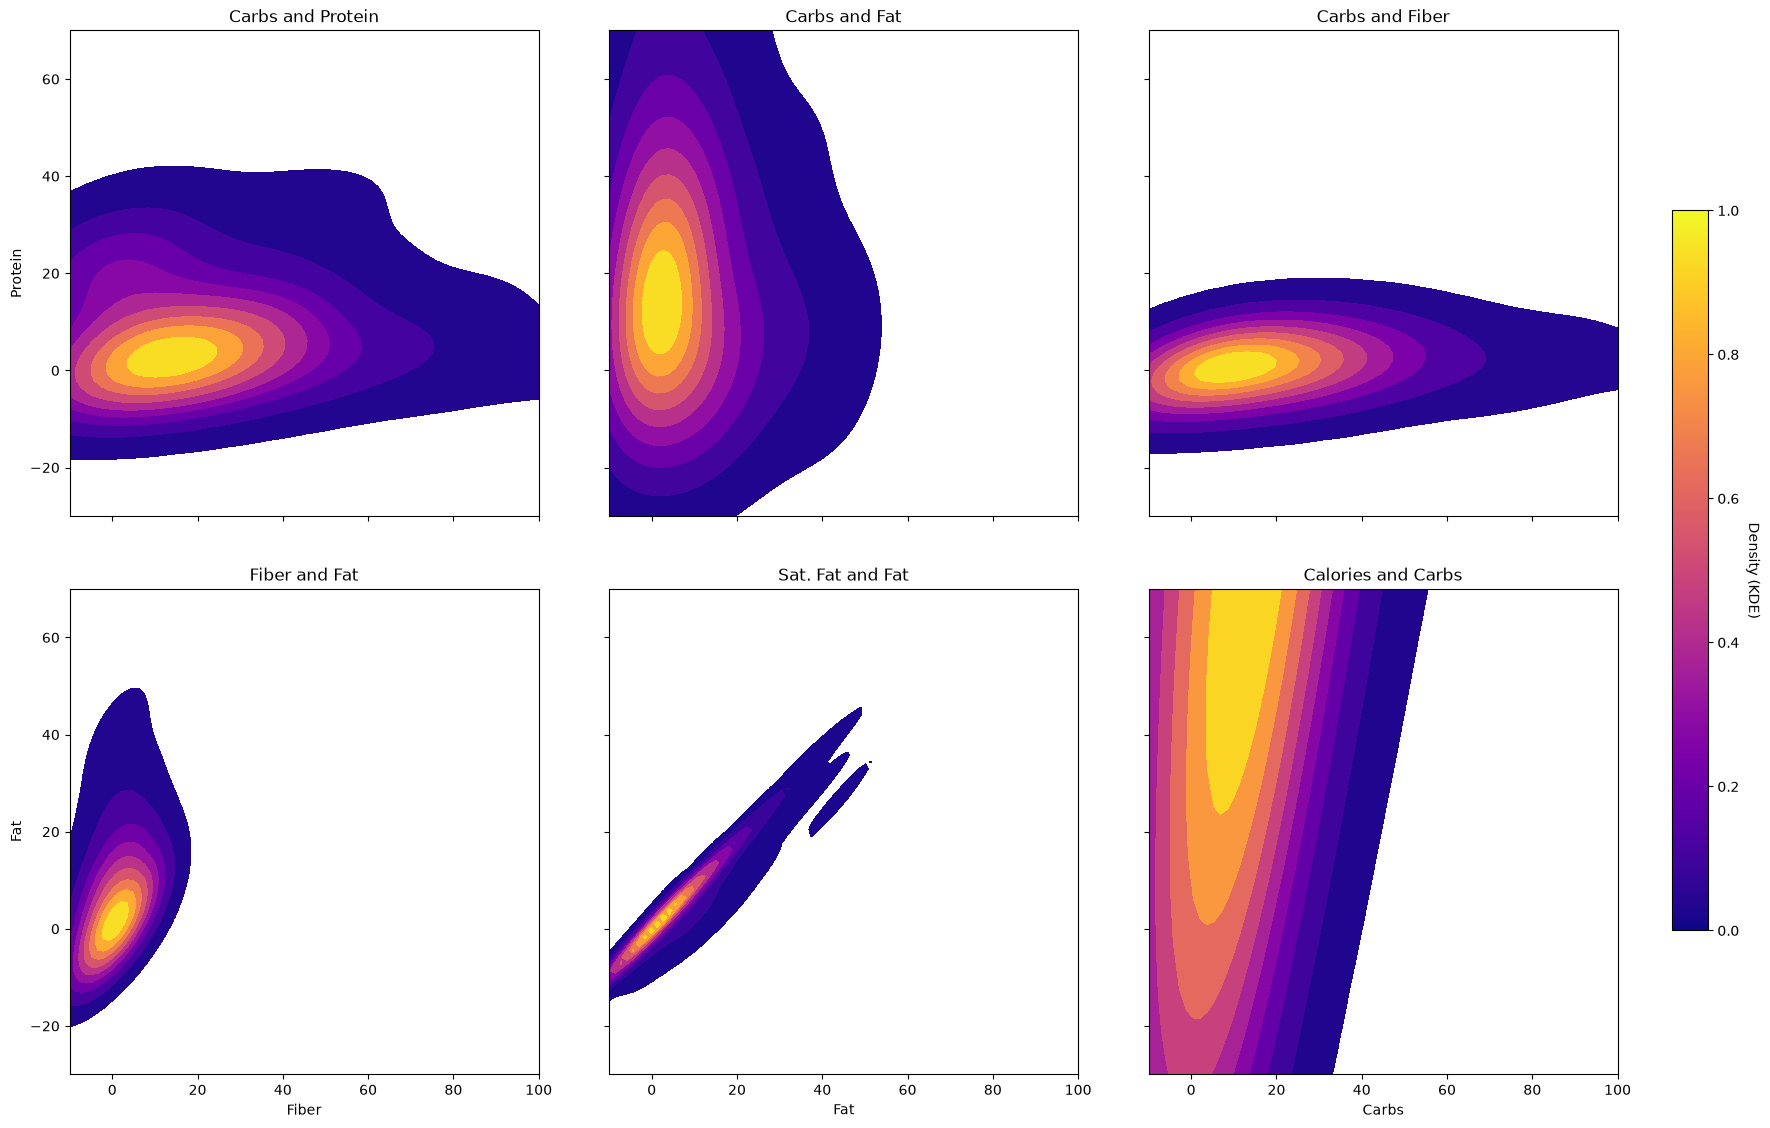

In [39]:
"""
This code generates multiple Kernel Density Estimation (KDE) plots to visualize 
the distribution and relationship between different nutrient variables. It creates 
a 2×3 grid of KDE plots using a plasma color map, where color intensity represents 
data density. A colorbar is added to provide a density scale for better interpretation.
"""

# Create a 2x3 grid for multiple KDE plots
import matplotlib.pyplot as plt
import matplotlib as mpl

f, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)

# Create a purple-style color map for KDE density visualization
cmap = sns.color_palette("plasma", as_cmap=True)

# Plot nutrient relationships using KDE with the selected color palette
sns.kdeplot(data=nutrients, x='Carbs', y='Protein', fill=True, cmap=cmap, ax=axes[0,0])
axes[0,0].set(xlim=(-10, 50), ylim=(-30, 70), title='Carbs and Protein')

sns.kdeplot(data=nutrients, x='Fat', y='Carbs', fill=True, cmap=cmap, ax=axes[0,1])
axes[0,1].set(xlim=(-10, 50), ylim=(-30, 70), title='Carbs and Fat')

sns.kdeplot(data=nutrients, x='Carbs', y='Fiber', fill=True, cmap=cmap, ax=axes[0,2])
axes[0,2].set(xlim=(-10, 50), ylim=(-30, 70), title='Carbs and Fiber')

sns.kdeplot(data=nutrients, x='Fiber', y='Fat', fill=True, cmap=cmap, ax=axes[1,0])
axes[1,0].set(xlim=(-10, 50), ylim=(-30, 70), title='Fiber and Fat')

sns.kdeplot(data=nutrients, x='Fat', y='Sat.Fat', fill=True, cmap=cmap, ax=axes[1,1])
axes[1,1].set(xlim=(-10, 50), ylim=(-30, 70), title='Sat. Fat and Fat')

sns.kdeplot(data=nutrients, x='Carbs', y='Calories', fill=True, cmap=cmap, ax=axes[1,2])
axes[1,2].set(xlim=(-10, 100), ylim=(-30, 70), title='Calories and Carbs')


# Create a separate colorbar axis on the right side
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar_ax = f.add_axes([0.94, 0.2, 0.02, 0.6])
cbar = f.colorbar(sm, cax=cbar_ax)
cbar.set_label('Density (KDE)', rotation=270, labelpad=15)

# Adjust spacing manually to avoid tight_layout warning
f.subplots_adjust(left=0.05, right=0.91, bottom=0.08, top=0.95, wspace=0.15, hspace=0.15)

## Now, we can explore individual metrics

In [46]:
# Let's answer this:
# Which food item has the highest protein content among vegetables and grains?

# Select food categories related to vegetables, grains, and nuts
alls = ['Vegetables A-E',
        'Vegetables F-P',
        'Vegetables R-Z',
        'Breads cereals fastfoodgrains',
        'Seeds and Nuts']

# Filter selected categories and sort protein content from low to high
prot = nutrients[nutrients['Category'].isin(alls)]

protein_rich = prot.sort_values(by='Protein', ascending=True)

# Select the 20 foods with the highest protein content
top_20 = protein_rich.tail(20)

# Create bar chart using Viridis color palette and display protein values
fig = px.bar(
    top_20,
    x='Food',
    y='Protein',
    color='Protein',
    text='Protein',
    title='Top 20 Protein Rich Foods',
    color_continuous_scale='Viridis'
)

# Show values on top of each bar and improve figure appearance
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.update_layout(template="plotly_white")

fig.show()

In [47]:
# Result:
# The bar chart presents the top 20 protein-rich foods among vegetables, grains, cereals, and nuts. 
# The results show that whole wheat has the highest protein content (~48 g), 
# followed by flour and white wheat slices (~39 g). 
# Soybeans also demonstrate a relatively high protein level (~22 g), 
# while most other selected foods contain moderate protein values ranging from 13 to 20 g. 
# Overall, the visualization highlights whole wheat, wheat-based products, and soybeans as the most important protein sources within these food categories.

## What foods we should avoid (high calory and bad foods)

In [50]:
"""
This code identifies the top 20 most calorie-rich foods and visualizes their calorie values.
A Plotly bar chart is created with a Plasma color scale and labels showing calorie amounts.
"""

# Sort foods based on calorie content from lowest to highest
# (highest calorie foods will appear on the right side of the chart)
cals = nutrients.sort_values(by='Calories', ascending=True)

# Select the top 20 calorie-rich foods
top_20_cals = cals.tail(20)

# Create bar chart with Plasma color palette and calorie values on bars
fig = px.bar(
    top_20_cals,
    x='Food',
    y='Calories',
    color='Calories',
    text='Calories',
    title='Top 20 Calorie Rich Foods',
    color_continuous_scale='Plasma'
)

# Display calorie values on top of each bar
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

# Improve figure appearance
fig.update_layout(template="plotly_white")

fig.show()

In [51]:
# ### Result:
# The bar chart presents the 20 foods with the highest calorie content in the dataset. 
# The results show that fortified milk has the highest calorie value (~1370 kcal), 
# followed by white slices, whole wheat, and dark sugar products with considerably high energy content. 
# Most of the selected high-calorie foods are energy-dense products such as processed foods, fats, dairy products, and sugar-based items. 
# Overall, the visualization highlights the main contributors to high calorie intake within the food dataset.

## Fatty foods



In [54]:
"""
This code identifies the top 20 foods with the highest fat content.
A Plotly bar chart is created to visualize fat levels with a Plasma color scale and value labels.
"""

# Sort foods based on fat content from lowest to highest
# (highest fat foods will appear on the right side of the chart)
fats = nutrients.sort_values(by='Fat', ascending=True)

# Select the top 20 fat-rich foods
top_20_fat = fats.tail(20)

# Create bar chart with Plasma color palette and fat values on bars
fig = px.bar(
    top_20_fat,
    x='Food',
    y='Fat',
    color='Fat',
    text='Fat',
    title='Top 20 Fat Rich Foods',
    color_continuous_scale='Plasma'
)

# Display fat values on top of each bar
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

# Improve figure appearance
fig.update_layout(template="plotly_white")

fig.show()

In [55]:
# Result:
# The bar chart presents the top 20 foods with the highest fat content in the dataset. 
# The results show that oysters have the highest fat value (~233 g), 
# followed by butter (~115 g), lard (~110 g), and hydrogenated cooking fat (~100 g). 
# Other high-fat foods include margarine, Brazil nuts, pork sausage, and various dairy and nut products. 
# Overall, the visualization indicates that the foods with the greatest fat content are mainly concentrated in animal fats, 
# processed fat products, dairy items, and nuts. 
# These results highlight the importance of considering both the quantity and source of dietary fat when evaluating the nutritional quality of foods.

## Let's analyze different food categories

By organizing the data into categories, we can summarize the values of different metrics and gain insights into patterns across categories.

In [56]:
category_dist=nutrients.groupby(['Category']).sum()
category_dist

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
Category,,,,,,,,,
Breads cereals fastfoodgrains,BiscuitsBran flakesBread cracked wheatRyeWhite...,11 cup1 slice1 slice1-lb. loaf1-lb. loaf1 slic...,5253,11921.0,403,207,99.0,115.91,2059.0
Dairy products,Cows' milkMilk skimButtermilkEvaporated undilu...,1 qt.1 qt.1 cup1 cup6 cups1 cup1 1/3 cups2/3 c...,7412,8434.0,503,396,322.0,4.40,651.0
Desserts sweets,Apple bettyBread puddingCakesChocolate fudgeCu...,1 serving3/4 cup1 slice1 slice11 slice1 slice1...,2958,6608.0,78,163,150.0,20.50,1184.0
DrinksAlcohol Beverages,BeerGinWinesTable (12.2% alcohol)Carbonated dr...,2 cups1 oz.1/2 cup1/2 cup12 oz.12 oz.12 oz.12 ...,3284,1112.0,0,0,0.0,0.00,167.0
Fats Oils Shortenings,YolksButterButterButterHydrogenated cooking fa...,21T.1/2 cup1/4 lb.1/2 cup1/2 cup1/2 cup1 T.1 T...,695,3629.0,234,631,536.0,234.00,239.0
Fish Seafood,ClamsCodCrab meatFish sticks friedFlounderHadd...,3 oz.3 1/2 oz.3 oz.53 1/2 oz.3 oz.3 1/2 oz.1 s...,1807,2757.0,588,338,252.0,235.00,263.0
Fruits A-F,Watercress stems rawApple juice cannedApple vi...,1 cup1 cup1/3 cup1 med1 cup1 cup1/2 cup3 med.1...,3844,3328.0,29,20,12.0,33.50,812.0
Fruits G-P,"Grapefruit sectionsGrapefruit fresh 5"" diamete...",1 cup1/21 cup1 cup1 cup1 cup1/2 cup6-oz. can6-...,5412,4054.0,28,25,21.0,21.10,1009.0
Fruits R-Z,RaisinsRaspberriesRaw redRhubarb sweetenedStra...,1/2 cup1/2 cup3/4 cup1 cup1 cup1 cupI med.1 wedge,1973,1228.0,7,1,0.0,17.40,330.0


In [62]:
# Group data by food category and calculate total values for each nutrient
category_dist = nutrients.groupby(['Category']).sum()

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px


# Create a 3x2 layout for pie charts
fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"type": "domain"}, {"type": "domain"}],
        [{"type": "domain"}, {"type": "domain"}],
        [{"type": "domain"}, {"type": "domain"}]
    ]
)

# New color palette while preserving category-color relationship
colors = px.colors.sequential.Viridis


# Function to create cleaner pie charts
def add_pie(values, title, row, col):
    fig.add_trace(
        go.Pie(
            values=values,
            labels=category_dist.index,
            title=title,
            marker=dict(
                colors=colors,
                line=dict(color='white', width=2)
            ),

            # Show only percentages, not category names
            textinfo='percent',

            # Hide very small percentages (<3%) to reduce clutter
            texttemplate='%{percent}',
            hovertemplate='%{label}<br>Value: %{value}<br>%{percent}',

            sort=False
        ),
        row=row,
        col=col
    )


add_pie(category_dist['Calories'].values, 'CALORIES', 1, 1)
add_pie(category_dist['Fat'].values, 'FAT', 1, 2)

add_pie(category_dist['Protein'].values, 'PROTEIN', 2, 1)
add_pie(category_dist['Fiber'].values, 'FIBER', 2, 2)

add_pie(category_dist['Sat.Fat'].values, 'SAT.FAT', 3, 1)
add_pie(category_dist['Carbs'].values, 'CARBS', 3, 2)


# Adjust layout and keep legend for category-color mapping
fig.update_layout(
    title_text="Category-wise Distribution of Nutritional Metrics",
    height=1100,
    width=1200,
    legend=dict(
        x=1,
        y=0.5
    )
)

fig.show()

In [63]:
# Inference:
# - The pie charts indicate that breads, grains, and cereals are the main contributors to total carbohydrate and calorie content.
# - Seafood represents one of the richest sources of protein among the analyzed food categories, while seeds and nuts contribute a considerable proportion of dietary fat.
# - Fruits generally have a limited contribution across most nutritional metrics, except for carbohydrates where they represent a noticeable share.
# - Dairy products show a higher contribution to saturated fat compared with seafood, highlighting differences in fat composition among food groups.

## Drinks, Alcohol, Beverages and Desserts

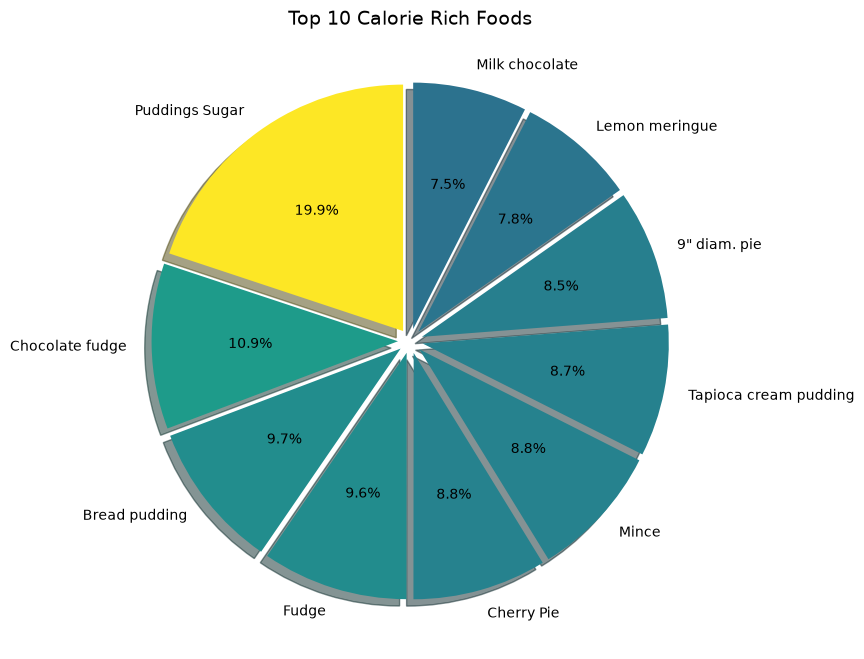

In [73]:
"""
This code visualizes the top 10 calorie-rich foods using a 3D-style pie chart.
The chart represents each food's contribution to the total calorie content.
"""

import matplotlib.pyplot as plt

# Select seafood and dessert categories
drinks = nutrients[nutrients['Category'].isin(['Fish Seafood', 'Desserts sweets'])]

# Select top 10 calorie-rich foods
drinks_top = drinks.sort_values(by='Calories', ascending=False).head(10)

# Prepare values and labels for the pie chart
values = drinks_top['Calories'].values
labels = drinks_top['Food'].values

# Create a 3D-style pie chart with shadow and separation effect
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.05]*10,
    colors=plt.cm.viridis(values / max(values))
)

# Add title
ax.set_title("Top 10 Calorie Rich Foods", fontsize=14)

plt.show()

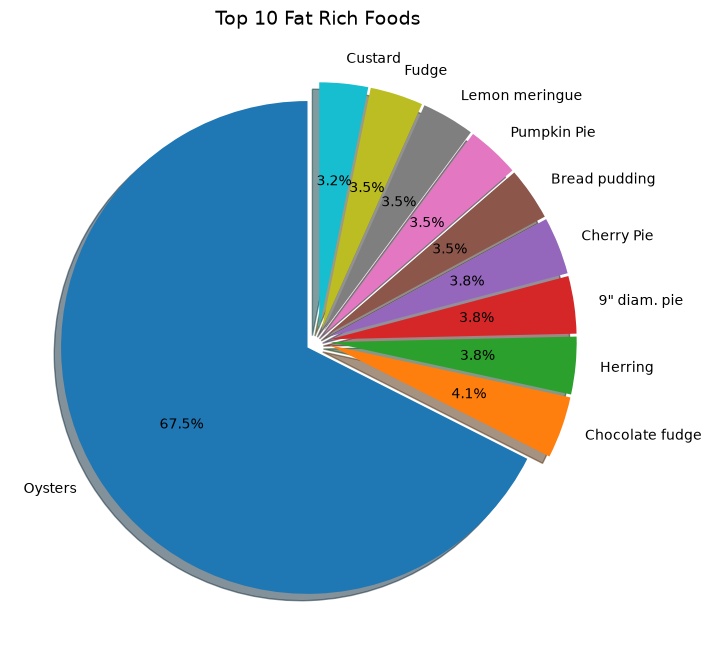

In [72]:
"""
This code visualizes the top 10 fat-rich foods using a 3D pie chart.
The chart shows each food's contribution to the total fat content.
"""

import matplotlib.pyplot as plt

# Sort foods based on fat content and select top 10 items
drinks_fatty = drinks.sort_values(by='Fat', ascending=False).head(10)

# Prepare values and labels for pie chart
values = drinks_fatty['Fat'].values
labels = drinks_fatty['Food'].values

# Create 3D-style pie chart
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.05]*10
)

# Add title
ax.set_title("Top 10 Fat Rich Foods", fontsize=14)

plt.show()

## meat, poultry , seafood.

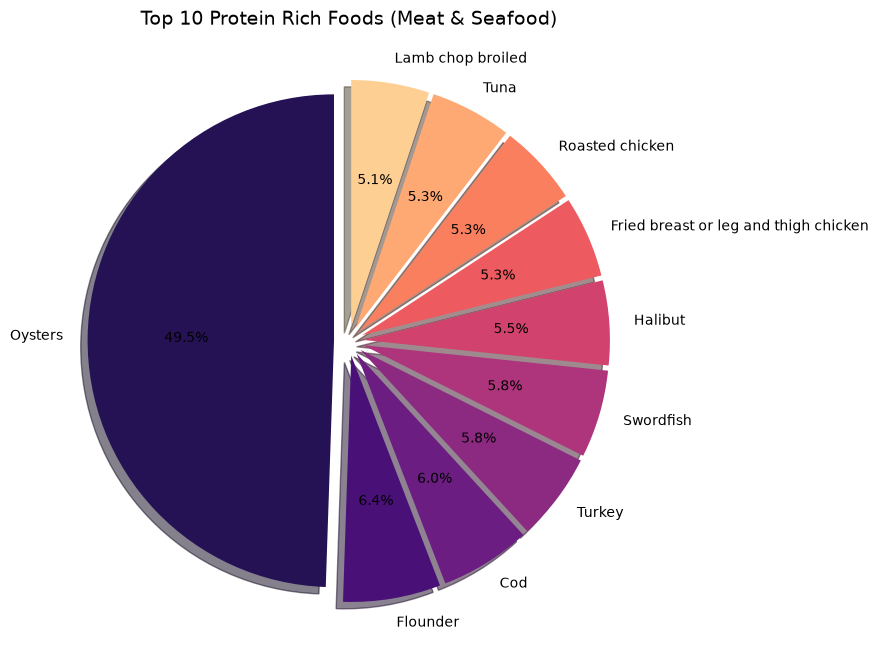

In [75]:
"""
This code visualizes the top 10 protein-rich foods from meat and seafood categories.
A 3D-style pie chart with an attractive color palette is used to show protein contribution.
"""

import matplotlib.pyplot as plt
import numpy as np

# Select meat and seafood categories
meat = nutrients[nutrients['Category'].isin(['Fish Seafood', 'Meat Poultry'])]

# Sort foods based on protein content and select top 10 items
meats_top = meat.sort_values(by='Protein', ascending=False).head(10)

# Prepare values and labels for the pie chart
values = meats_top['Protein'].values
labels = meats_top['Food'].values

# Create a 3D-style pie chart with attractive colors
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.magma(np.linspace(0.15, 0.9, len(values)))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.06] * len(values),
    colors=colors
)

# Add title
ax.set_title("Top 10 Protein Rich Foods (Meat & Seafood)", fontsize=14)

plt.show()

## Seafood and meat always = having good fat content

In [89]:
"""
This code visualizes the top 10 fattest meat and seafood products using a bubble chart.
Bubble size and color are normalized based on fat content for better comparison.
"""

import plotly.graph_objects as go
import numpy as np

# Sort foods based on fat content (highest values appear on the left)
top_10_fattest = meat.sort_values(by='Fat', ascending=False).head(10)

# Normalize bubble sizes to avoid extremely large bubbles
bubble_sizes = np.interp(
    top_10_fattest['Fat'],
    (top_10_fattest['Fat'].min(), top_10_fattest['Fat'].max()),
    (40, 120)
)

# Create bubble chart
fig = go.Figure(
    data=[
        go.Scatter(
            x=top_10_fattest['Food'],
            y=top_10_fattest['Fat'],
            mode='markers+text',

            marker=dict(
                size=bubble_sizes,
                color=top_10_fattest['Fat'],
                colorscale='Plasma',
                showscale=True,
                colorbar=dict(title="Fat"),
                opacity=0.85,
                line=dict(color='white', width=2)
            ),

            text=top_10_fattest['Fat'],
            textposition="middle center",
            textfont=dict(
                color="white",
                size=12
            )
        )
    ]
)


# Improve visualization
fig.update_layout(
    title="Top 10 Meat/Seafood Foods with Highest Fat Content",
    template="plotly_white",
    height=650,
    width=1000,

    xaxis_title="Food",
    yaxis_title="Fat Content (g)",

    # Use realistic fat range
    yaxis=dict(
        range=[0, top_10_fattest['Fat'].max() + 30]
    ),

    xaxis=dict(
        tickangle=-35
    )
)

fig.show()

## Exploring the meat with most fiber

In [87]:
top_10_fibrous= meat.sort_values(by='Fiber', ascending=False)
top_10_fibrous=top_10_fibrous.head(10)
top_10_fibrous

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
82,Oysters,6-8 med.,230,231.0,232,233,234.0,235.0,236.0,Fish Seafood
44,Beef,3 oz.,85,245.0,23,16,15.0,0.0,0.0,Meat Poultry
43,Bacon,2 slices,16,95.0,4,8,7.0,0.0,1.0,Meat Poultry
46,Ground lean,3 oz.,85,185.0,24,10,9.0,0.0,0.0,Meat Poultry
47,Roast beef,3 oz.,85,390.0,16,36,35.0,0.0,0.0,Meat Poultry
48,Steak,3 oz.,85,330.0,20,27,25.0,0.0,0.0,Meat Poultry
45,Hamburger,3 oz.,85,245.0,21,17,15.0,0.0,0.0,Meat Poultry
50,Corned beef,3 oz.,85,185.0,22,10,9.0,0.0,0.0,Meat Poultry
51,Corned beef hash canned,3 oz.,85,120.0,12,8,7.0,0.0,6.0,Meat Poultry
52,Corned beef hash Dried,2 oz.,56,115.0,19,4,4.0,0.0,0.0,Meat Poultry


Bacon, Halibut, Turkey and veal top the charts in terms of Fiber content.

## Introducing 3D Scatter Plots - Intractive with Plotly


In [90]:
# 3D scatter plots are used to visualize relationships among three variables 
# by representing data points across three different axes. 
# Each observation in the dataset is displayed as a marker, where its location is 
# determined by the corresponding values assigned to the X, Y, and Z axes. In other words, 
# it extends a traditional 2D scatter plot by adding a third dimension to better represent complex relationships between variables.

# Although 3D scatter plots may not always provide deep analytical insights, 
# they are useful for visual exploration and can offer an attractive way to observe patterns and distributions within the data.

In [91]:
trace1 = go.Scatter3d(
    x=nutrients['Category'].values,
    y=nutrients['Food'].values,
    z=nutrients['Fat'].values,
    text=nutrients['Food'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
        sizeref=750,
        color=nutrients['Fat'].values,
        colorscale='Viridis',
        colorbar=dict(title='Total Fat (% Daily Value)'),
        line=dict(color='rgb(255, 255, 255)')
    )
)

data=[trace1]

layout=dict(
    height=800,
    width=800,
    title='3D Scatter Plot of Fatty foods (% Daily Value)'
)

fig=dict(data=data, layout=layout)

py.iplot(fig, filename='3DBubble')

In [93]:
trace1 = go.Scatter3d(
    x=nutrients['Category'].values,
    y=nutrients['Food'].values,
    z=nutrients['Carbs'].values,
    text=nutrients['Food'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
        sizeref=750,
        color=nutrients['Carbs'].values,
        colorscale='Viridis',
        colorbar=dict(title='Total Carbohydrates (% Daily Value)'),
        line=dict(color='rgb(255, 255, 255)')
    )
)

data=[trace1]

layout=dict(
    height=800,
    width=800,
    title='3D Scatter Plot of Carbohydrate Rich Foods'
)

fig=dict(data=data, layout=layout)

py.iplot(fig, filename='3DBubble')

## Food with highest calories

C:\Users\User\AppData\Local\Temp\ipykernel_22604\3670275453.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxenplot(


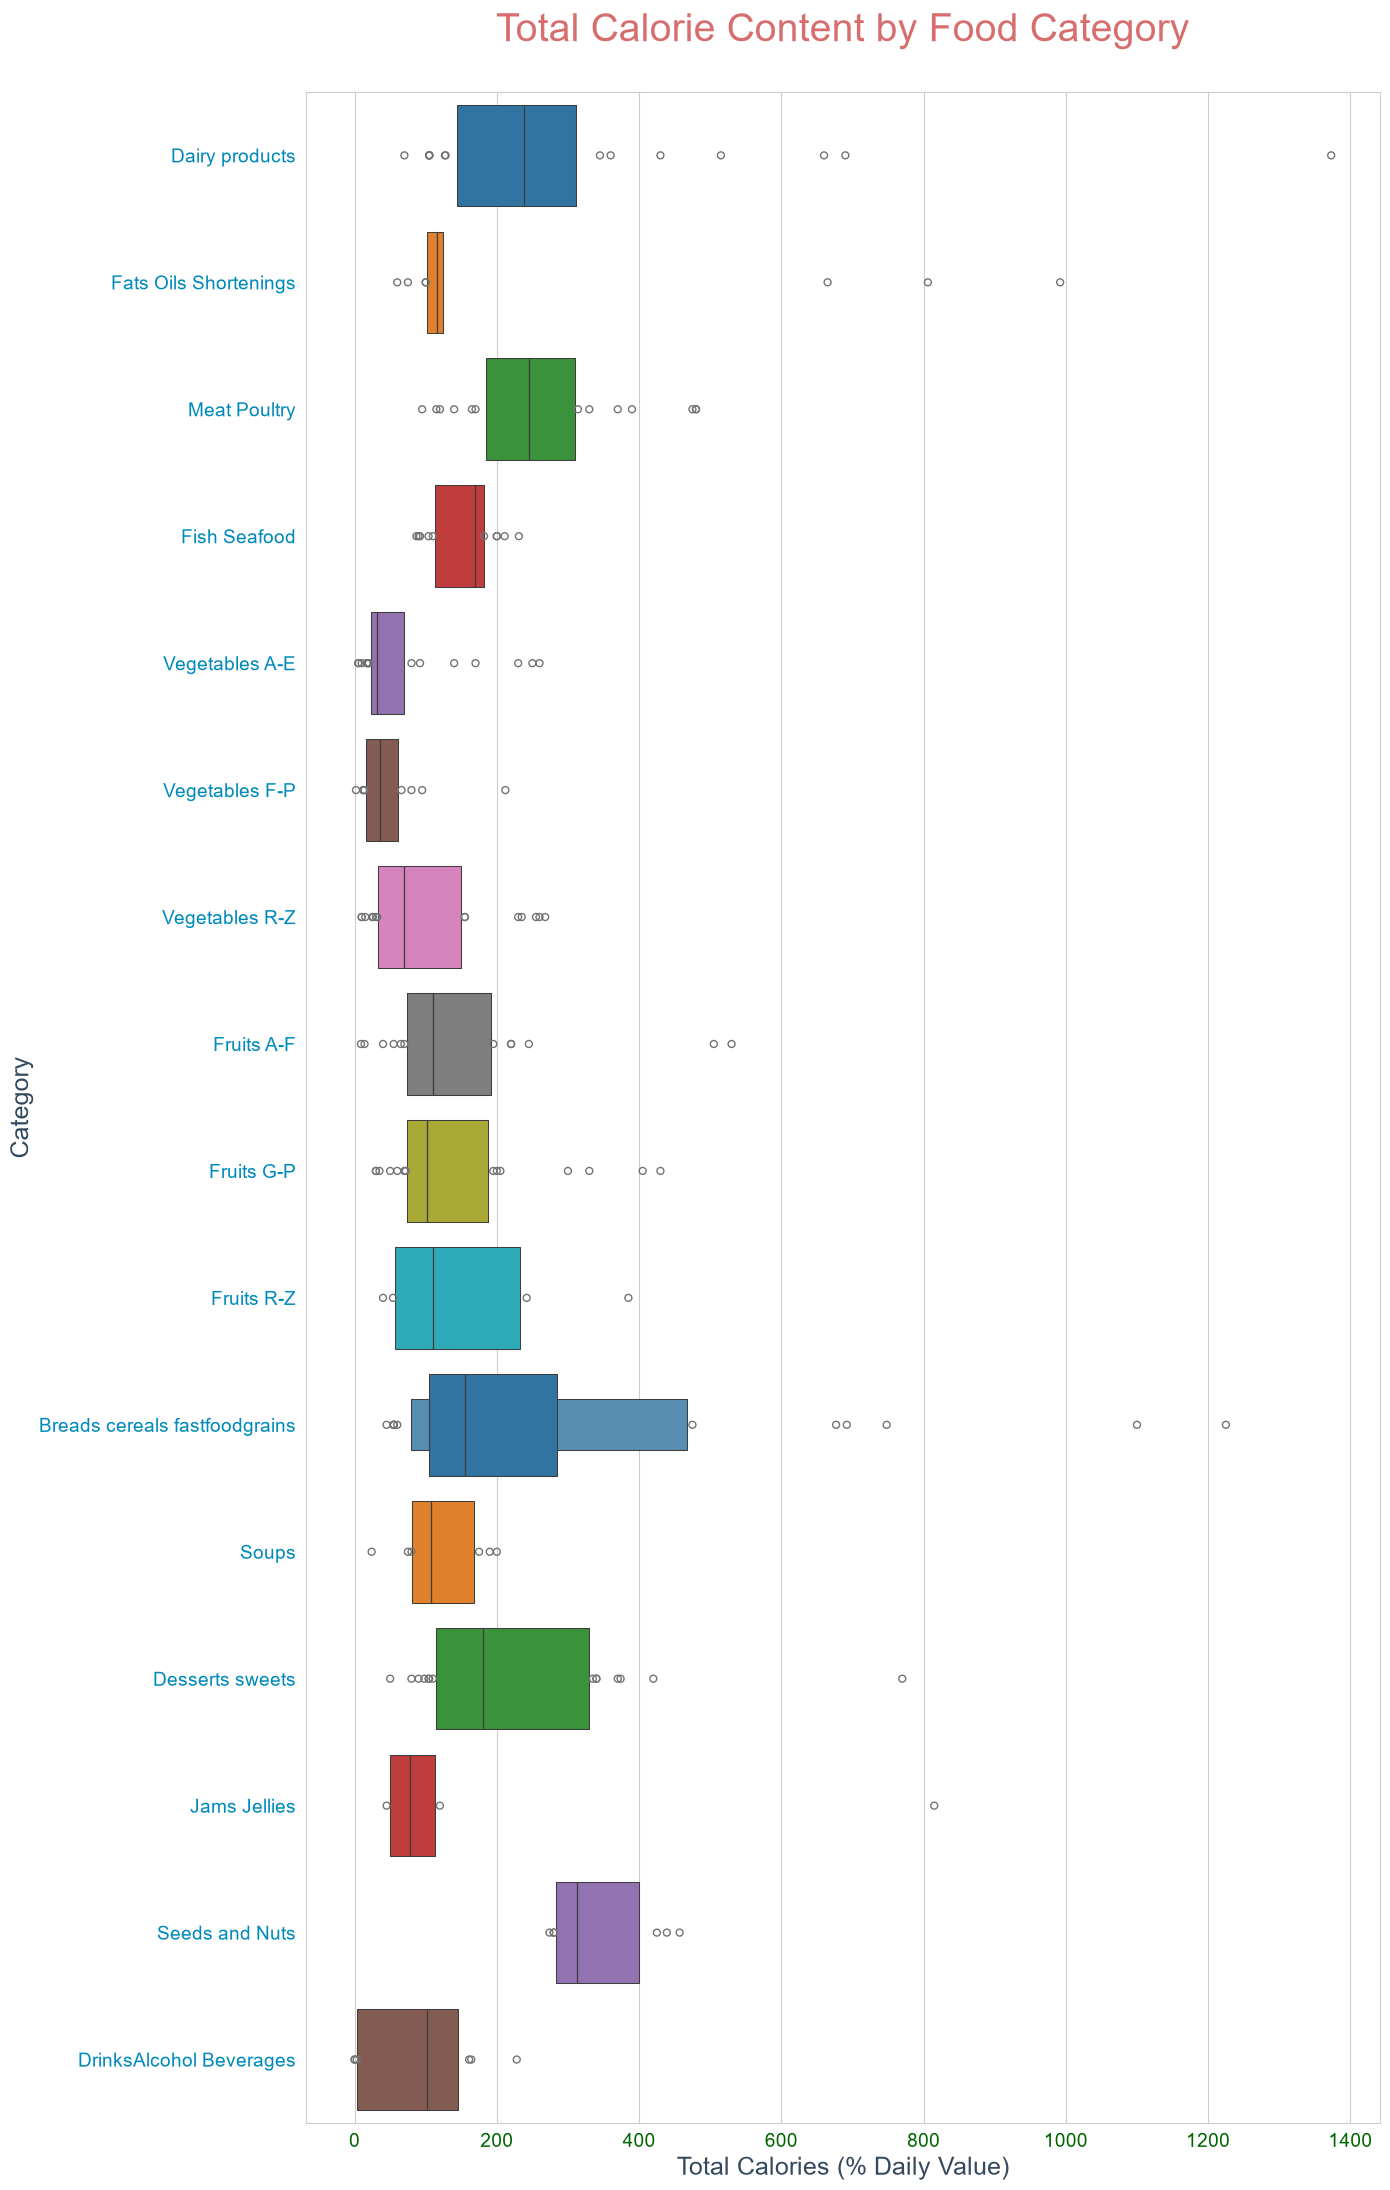

In [96]:
sns.set_style("whitegrid")

plt.figure(figsize=(14, 22))

# Create horizontal boxen plot
ax = sns.boxenplot(
    y="Category",
    x='Calories',
    data=nutrients,
    palette="tab10"
)

# Add transparency to colors
for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .9))

# Customize title and axis labels
plt.title(
    "Total Calorie Content by Food Category\n",
    loc="center",
    size=28,
    color='#be0c0c',
    alpha=0.6
)

plt.xlabel(
    'Total Calories (% Daily Value)',
    color='#34495E',
    fontsize=18
)

plt.ylabel(
    'Category',
    color='#34495E',
    fontsize=18
)

# Adjust tick appearance
plt.xticks(
    size=14,
    color='#006600'
)

plt.yticks(
    size=14,
    color='#008abc'
)

plt.tight_layout()

plt.show()

Thank you for your attention.